<a href="https://colab.research.google.com/github/nurainazuhar/Assignment_1_Data_Management/blob/main/IrisClassification_Assignment1_STQD6324.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Species Classification Workflow

This notebook demonstrates a complete machine learning workflow for classifying Iris species using PySpark. The process covers data loading, preprocessing, model training and hyperparameter tuning for several classification algorithms, and finally, model evaluation and comparative analysis.

## Workflow Steps:

1.  **Loading Data**: The Iris dataset is loaded into a Spark DataFrame.
2.  **Data Preprocessing**: Categorical species labels are converted into numerical labels, and features are assembled into a vector format suitable for machine learning models.
3.  **Data Splitting**: The dataset is divided into training and testing sets to evaluate model performance on unseen data.
4.  **Model Training and Hyperparameter Tuning**: Three different classification models: Decision Tree, Random Forest, and Support Vector Machine (SVM) are trained. Hyperparameters for each model are tuned using cross-validation to find the optimal settings.
5.  **Model Prediction and Evaluation**: The best-performing version of each model is used to make predictions on the test set. Performance metrics, including accuracy, precision, recall, and F1-score, are calculated and visualized using confusion matrices.
6.  **Comparative Analysis**: The performance of all models is compared, and the best-performing model is identified, along with a discussion of its strengths and limitations.

In [ ]:
# This cell installs the PySpark library, which is necessary for running Spark applications in Python.
# It only needs to be run once.
!pip install pyspark

In [ ]:
# Load necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.classification import LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from sklearn.metrics import confusion_matrix

In [ ]:
# Initialize Spark
spark = SparkSession.builder.appName("IrisClassification").getOrCreate()

This code block creates or retrieves a **SparkSession**, which is the entry point for programming Spark with DataFrames and Datasets:

| Code Snippet                               | Explanation                                                                                                                                                                                                                                      |
| :----------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **SparkSession.builder**                 | Provides a builder interface for configuring and creating a `SparkSession` instance.                                                         |
| **.appName("IrisClassification")**     | Sets a human-readable name for Spark application (e.g., "IrisClassification").                                                       |
| **.getOrCreate()**                       | *   Gets an existing `SparkSession` if one has already been created with the same configuration.
|                                            | *   Or, if no existing session matches, creates a new `SparkSession` instance based on the options set in the builder.

## **1. Loading data**

This steps include downloading the Iris dataset and loading it into a PySpark DataFrame, making it ready for further processing and analysis.

In [ ]:
import requests
filename = "iris.csv"
# URL of the dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

# Check if the file already exists to avoid re-downloading
if not os.path.exists(filename):
    # Send a GET request to download the file content
    response = requests.get(url)
    # Open the file in binary write mode and save the content
    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"{filename} downloaded successfully.")
else:
    print(f"{filename} already exists. Skipping download.")

iris.csv already exists. Skipping download.


In [ ]:
# Load data into Spark dataframe from the default working directory
df = spark.read.csv("iris.csv", header=True, inferSchema=True)
df.show(5)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


## **2.0 Data Preprocessing**

This section prepares the raw Iris dataset for machine learning. It involves converting categorical labels into numerical formats and assembling numerical features into a single vector, which are essential steps before training any classification model.

In [ ]:
# Convert categorical variables (species) to dummy variables(0, 1, 2)
indexer = StringIndexer(inputCol="species", outputCol="label")
df_indexed = indexer.fit(df).transform(df)
df_indexed.show(5)

+------------+-----------+------------+-----------+-------+-----+
|sepal_length|sepal_width|petal_length|petal_width|species|label|
+------------+-----------+------------+-----------+-------+-----+
|         5.1|        3.5|         1.4|        0.2| setosa|  0.0|
|         4.9|        3.0|         1.4|        0.2| setosa|  0.0|
|         4.7|        3.2|         1.3|        0.2| setosa|  0.0|
|         4.6|        3.1|         1.5|        0.2| setosa|  0.0|
|         5.0|        3.6|         1.4|        0.2| setosa|  0.0|
+------------+-----------+------------+-----------+-------+-----+
only showing top 5 rows


This code block converts the categorical `species` column into numerical labels:

| Code Snippet                                              | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **indexer = StringIndexer(inputCol="species", outputCol="label")** | Initializes a `StringIndexer`. Convert the `species` column into a new `label` column with numbers.                                                                                                                                                                                |
| **df_indexed = indexer.fit(df).transform(df)**          | This performs two key steps:
|                                                           | *   **.fit(df)**: Takes the `species` column, and assigns a numerical index to each (e.g., 'setosa' -> 0.0, 'versicolor' -> 1.0, 'virginica' -> 2.0).
|                                                           | *   **.transform(df)**: Applies those assignments to create the new `label` column. The result is stored in `df_indexed`.                                                                                                                                                   |
| **.show(5)**                                  | Displays the first 5 rows of the `df_indexed` DataFrame.

In [ ]:
# Define features variables
assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features")

# Transform the data using the assembler and select only the features and label columns
data = assembler.transform(df_indexed).select("features", "label")
data.show(5)

+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows


This code block prepares the data for machine learning models by combining several columns into a single 'features' column:

| Code Snippet                      | Explanation                                                                                                                                                                                                                                                                                                                                       |
| :-------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **VectorAssembler**             | Combines a given list of numerical columns into a single vector column.                                                                                                                                                                                                 |
|                                   | *   This is a common requirement for Spark ML algorithms
|                                   | *   It allows machine learning models to treat all these individual numerical features as a single input vector for training.                                                                                                                                                                                                                          |
| **.transform(df_indexed)**      | Applies the `VectorAssembler` to the `df_indexed` DataFrame, creating the `features` vector column from the specified input columns.                                                                                                                                                                                                            |
| **.select("features", "label")** | Selects only the newly created `feature` column and the `label` column . These two columns will be used as the input for subsequent model training and evaluation.

## **3. Split the data**

This step divides the preprocessed dataset into two subsets: a training set and a testing set. This is crucial for evaluating how well a model generalizes to new, unseen data, preventing overfitting, and providing an unbiased assessment of its performance.

In [ ]:
# Split the data into training and testing sets.
# 80% of the data will be used for training, and 20% for testing.
# 'seed=42' ensures that the split is reproducible, meaning the same random split will occur each time the code is run.
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

# Print the number of rows in the training and testing datasets to verify the split.
print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())

Training rows: 126
Testing rows: 24


## **4. Train and tune hyperparameters of the model**

This part focuses on selecting the best machine learning model for the classification task by training and optimizing three different models: **Decision Tree, Random Forest and Support Vector Machine**. For each model, the steps below will be perform:

1.  **Model Definition**: Initialize the model with basic parameters.
2.  **Hyperparameter Tuning (Grid Search)**: Create a grid of hyperparameters (settings) to test for the model. Hyperparameters are parameters whose values are set before the learning process begins, unlike model parameters which are learned during training.
3.  **Cross-Validation**: Use a `CrossValidator` to evaluate different combinations of hyperparameters on the training data. This helps in finding the best performing set of hyperparameters, preventing overfitting.
4.  **Model Fitting**: Train the model using the best hyperparameters found by cross-validation on the `train_data`.

### **Model 1: Decision Tree**

Decision Trees are a good choice for the Iris dataset because:

*   **Interpretability**: Decision Trees are easy to understand and visualize, making it clear how decisions are made based on the features (e.g., 'petal length > X').

*   **Non-linear relationships**: They can capture complex, non-linear relationships between features and the target variable, which might be present even in a simple dataset like Iris.

*   **Effectiveness with small datasets**: For smaller, well-behaved datasets like Iris, Decision Trees often perform very well, sometimes achieving perfect separation.

*   **Handles numerical and categorical data**: While the `species` column is converted to numerical labels, Decision Trees can inherently work with both types of data, which is common in many datasets.

*    **Automatic Feature Selection**: The algorithm identifies which features are the most important, effectively ignoring less relevant variable.

In [ ]:
# Define the model
dt = DecisionTreeClassifier(labelCol="label",featuresCol="features",seed=42)

This code block defines the **Decision Tree Classifier**:

| Code Snippet                        | Explanation                                                                                                                                                                                                                                                          |
| :---------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **dt = DecisionTreeClassifier**       | Initializes a Decision Tree model.                                                                                                                                                                                                                   |
| **labelCol="label"**                | Specifies that the `label` column (target variable) should be used for training.                                                                                                                                                                                       |
| **featuresCol="features"**          | Specifies that the `features` column (input features) should be used.                                                                                                                                                                                                  |
| **seed=42**                           | Sets a random seed for reproducibility.

In [ ]:
# Build Grid Search (list of settings to try)
dt_grid = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [3, 5, 10])           #try 3 different depth values
    .addGrid(dt.impurity, ["gini", "entropy"])  #try two split formulas
    .build()
)

This code block sets up the **hyperparameter grid for the Decision Tree** using `ParamGridBuilder`:

| Code Snippet                                | Explanation                                                                                                                                                                                                                                                          |
| :------------------------------------------ | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ParamGridBuilder()**                       | Starts building a grid of parameters to search over.                                                                                                                                                                                                                 |
| **.addGrid(dt.maxDepth, [3, 5, 10])**        | Adds `maxDepth` (the maximum depth of the tree) as a hyperparameter to tune. It will test depths of 3, 5, and 10.                                                                                                                                                                     |
| **.addGrid(dt.impurity, ["gini", "entropy"])** | Adds `impurity` (the criterion used for information gain) as a hyperparameter. It will test both 'gini' and 'entropy'.                                                                                                                                                                 |
| **.build()**                                  | Finalizes the grid. The `CrossValidator` will test every combination of these `maxDepth` and `impurity` values.

In [ ]:
# Cross Validator
dt_cv = CrossValidator(
    estimator=dt,                    #the model to tune
    estimatorParamMaps=dt_grid,      #the grid of settings to try
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"              # F1-Score is chosen to balance precision and recall, providing a comprehensive view of model performance.
                                     # For balanced datasets like Iris, accuracy is also a strong choice.
    ),
    numFolds=3,                      #split training data into 3 folds
    seed=42
)

This code block configures the **Cross-Validator for the Decision Tree**:

| Code Snippet                                              | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **CrossValidator()**                                 | Creates a `CrossValidator` object, to find the best model.                                                                                                                                                                                                                |
| **estimator=dt**                                        | Specifies `dt` (the initialized `DecisionTreeClassifier` model) as the estimator (the model to be tuned).                                                                                                                                                                                                                   |
| **estimatorParamMaps=dt_grid**                          | Provides the `dt_grid` (the hyperparameter grid created earlier) as the set of parameter combinations that the `CrossValidator` should try.                                                                                                                                                                                                                                                                                                        |
| **evaluator=MulticlassClassificationEvaluator()**    | An evaluator to measure the model's performance for multi-class classification.                                                                                                                                                                                                                            |
| **labelCol="label"**                                  | Specifies that the `label` column is the true label against which predictions will be compared.                                                                                                                                                                                                                              |
| **metricName="f1"**                                   | Specifies that the F1-Score should be used as the primary metric to optimize during cross-validation. The `CrossValidator` will select the model that yields the highest average F1-Score.                                                                                                                                                                |
| **numFolds=3**                                          | Specifies 3-fold cross-validation. This means the training data will be split into 3 subsets. The model will be trained 3 times, each time using 2 subsets for training and 1 for validation.                                                                                                                                                   |

In [ ]:
# Fit the decision tree model using training data
dt_cv_model = dt_cv.fit(train_data)

This code block **fits (trains) the Decision Tree model** using cross-validation:

| Code Snippet                          | Explanation                                                                         |
| :------------------------------------ | :---------------------------------------------------------------------------------- |
| **dt_cv_model = dt_cv.fit(train_data)** | Trains the Decision Tree model by:
|                                       | *   Iterating all hyperparameter combos in `dt_grid`.
|                                       | *   Using 3-fold cross-validation on `train_data`.
|                                       | *   Evaluating models with F1-Score.
|                                       | *   Selecting and returning the best model as `dt_cv_model`.

In [ ]:
# Display best parameters found by CrossValidator
dt_best = dt_cv_model.bestModel
print("\nBest parameters found:")
print(f"     maxDepth  = {dt_best.depth}")
print(f"     impurity  = {dt_best.extractParamMap().get(dt.impurity)}")


Best parameters found:
     maxDepth  = 3
     impurity  = entropy


The output shows:

*   **maxDepth = 3**: The CrossValidator found that a Decision Tree with a maximum depth of 3 achieved the highest F1-Score on the training data.
*   **impurity = entropy**: 'Entropy' was identified as the best criterion for splitting the data at each node and it led to a better performing DT model.


### **Model 2: Random Forest**

Random Forest is a suitable choice for the Iris dataset for several reasons:

*   **Ensemble Learning**: Random Forest is an ensemble method that builds multiple decision trees and combines their predictions. This often leads to higher accuracy and better generalization than a single decision tree.
*   **Robustness to Overfitting**: By using majority voting from many decision trees, it reduces the variance and overfitting often seen in a single decision tree model.
*   **Feature Importance**: Random Forests can also provide insights into feature importance, indicating which features (e.g., petal length, petal width) are most influential in classifying the Iris species.
*   **Handles Non-linearity**: Like single decision trees, Random Forests can effectively capture complex, non-linear relationships within the data.
*   **Fast and Effective**:  Despite its complexity, it provides rapid results and works well on small datasets like Iris without requiring intense hyper-parameter tuning.

In [ ]:
# Define the model
rf = RandomForestClassifier(labelCol="label",featuresCol="features",seed=42)

This code block defines the **Random Forest Classifier**:

| Code Snippet                        | Explanation                                                                                                                                                                                                                                                          |
| :---------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **rf = RandomForestClassifier()**       | Initializes a Random Forest model.                                                                                                                                                                                    |
| **labelCol="label"**                | Sets `label` as the target variable.                                                                                                                                                                                       |
| **featuresCol="features"**          | Sets `features` as the input features.                                                                                                                                                                                                  |

In [ ]:
# Build Grid Search (list of settings to try)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,             [20, 50, 100])      #try 3 forest sizes
    .addGrid(rf.maxDepth,             [5, 10])            #try 2 depth levels
    .addGrid(rf.featureSubsetStrategy,["sqrt", "log2"])   #try 2 feature strategies
    .build()
)

This code block sets up the **hyperparameter grid for Random Forest**:

| Code Snippet                            | Explanation                                                                                                                                                                                                                                                          |
| :-------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ParamGridBuilder()**                   | Initializes the grid builder.                                                                                                                                                                                                                 |
| **.addGrid(rf.numTrees, [20, 50, 100])** | Adds `numTrees` (number of trees) to test 20, 50, and 100 trees, balancing performance and cost.                                                                                                                                                                     |
| **.addGrid(rf.maxDepth, [5, 10])**        | Adds `maxDepth` (max tree depth) to test 5 and 10, controlling tree complexity.                                                                                                                                                                 |
| **.addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])** | Adds `featureSubsetStrategy` to test 'sqrt' and 'log2', randomizing feature selection for tree diversity.                                                                                                                                                                     |
| **.build()**                             | Finalizes the grid, creating all parameter combinations for `CrossValidator`.

In [ ]:
# Cross Validator
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"
    ),
    numFolds=3,     #3-fold cross-validation
    seed=42
)

This code block configures the **Cross-Validator for Random Forest**:

| Code Snippet                                              | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **CrossValidator()**                                 | Creates a `CrossValidator` object for hyperparameter tuning.                                                                                                                                                                                                                 |
| **estimator=rf**                                        | Specifies `rf` (Random Forest model) as the estimator.                                                                                                                                                                                                                   |
| **estimatorParamMaps=rf_grid**                          | Provides `rf_grid` (hyperparameter combinations) to explore.                                                                                                                                                                                                                                          |
| **evaluator=MulticlassClassificationEvaluator()**    | Defines the evaluator for model performance.                                                                                                                                                                                                                            |
| **labelCol="label"**                                  | Sets `label` as the true target for comparison.                                                                                                                                                                                                                              |
| **metricName="f1"**                                   | Optimizes for F1-Score, balancing precision and recall.                                                                                                                                                                                                           |
| **numFolds=3**                                          | Uses 3-fold cross-validation for robust performance estimation.                                                                                                                                                   |
|

In [ ]:
# Fit the random forest model using training data
rf_cv_model = rf_cv.fit(train_data)

This code block **fits (trains) the Random Forest model** using cross-validation:

| Code Snippet                          | Explanation                                                                         |
| :------------------------------------ | :---------------------------------------------------------------------------------- |
| **rf_cv_model = rf_cv.fit(train_data)** | Trains the Random Forest model by:
|                                       | *   Iterating all hyperparameter combos in `rf_grid`.
|                                       | *   Using 3-fold cross-validation on `train_data`.
|                                       | *   Evaluating models with F1-Score.
|                                       | *   Selecting and returning the best model as `rf_cv_model`.

In [ ]:
# Display best parameters found by CrossValidator
rf_best = rf_cv_model.bestModel
print("\nBest parameters found:")
print(f"     numTrees = {rf_best.getNumTrees}")
# To get maxDepth, need to access the parameter from the estimator's map
print(f"     maxDepth = {rf_best.extractParamMap().get(rf.maxDepth)}")


Best parameters found:
     numTrees = 50
     maxDepth = 5


The output shows:

+ **numTrees = 50**: Using 50 decision trees in the forest achieved the best F1-Score. More trees generally lead to more robust models but also increase computation time.
+ **maxDepth = 5**: A maximum depth of 5 for each individual tree within the forest was determined to be optimal. This limits the complexity of each tree, helping to prevent overfitting and improve generalization.


### **Model 3: Support Vector Machine (SVM)**

Support Vector Machines (SVMs) are effective for the Iris dataset because:

*   **Clear Margin Maximization**: SVMs aim to find the best hyperplane that maximally separates the classes. For a dataset like Iris, where classes are often well-separated, this can lead to excellent classification.
*   **Handles Feature Overlap**: SVMs deal with this using the soft-margin parameter to allow for slight misclassifications, or by utilizing non-linear kernels.
*   **Efficiency**: It can compute decision boundaries quickly and use less memory than other machine learning methods.
*   **Robustness with Small Datasets**: SVMs can perform well and are highly resistant to overfitting even with smaller datasets.

In [ ]:
# Define the base SVM model (binary classifier)
svm_base = LinearSVC(labelCol="label", featuresCol="features", maxIter=10)

# Wrap LinearSVC in OneVsRest for multi-class classification
svm = OneVsRest(classifier=svm_base, labelCol="label", featuresCol="features")

This code block defines the **Support Vector Machine (SVM) model** using `LinearSVC` and `OneVsRest`:

| Code Snippet                                                                | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **svm_base = LinearSVC()**                                        | Initializes the base `LinearSVC`, which is a binary classifier.                                                                                                                                                                                                                                  |
| **svm = OneVsRest(classifier=svm_base)`**                       | Wraps `LinearSVC` with `OneVsRest` to adapt it for multi-class classification (more than two class). `OneVsRest` trains multiple binary classifiers, one for each class versus all others.                                                                                                                                                                                                                         |
| **labelCol="label", featuresCol="features"**                  | These parameters specify the input label column and the input features column for the models.

In [ ]:
# Build Grid Search (list of settings to try)
svm_grid = (
    ParamGridBuilder()
    .addGrid(svm_base.regParam, [0.01, 0.1, 1.0])  # try 3 regularization strengths

    .build()
)


This code block sets up the **hyperparameter grid for LinearSVC (SVM)**:

| Code Snippet                            | Explanation                                                                                                                                                                                                                                                          |
| :-------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ParamGridBuilder()**                 | Initializes the grid builder.                                                                                                                                                                                                                 |
| **.addGrid(svm.regParam, [0.01, 0.1, 1.0])** | Adds `regParam` (regularization parameter) to test values 0.01, 0.1, and 1.0. Regularization strength: Controls the trade-off between maximizing the margin width and minimizing training errors. It helps prevent overfitting by penalizing large coefficients.                                                                                                                                                                                                                                   |
| **.build()**                         | Finalizes the grid, creating all parameter combinations for `CrossValidator`.

In [ ]:
# Cross Validator
svm_cv = CrossValidator(
    estimator=svm,
    estimatorParamMaps=svm_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"
    ),
    numFolds=3,
    seed=42
)


This code block configures the **Cross-Validator for LinearSVC (SVM)**:

| Code Snippet                                              | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **CrossValidator()**                                 | Creates a `CrossValidator` object for hyperparameter tuning.                                                                                                                                                                                                                 |
| **estimator=svm**                                     | Specifies `svm` (LinearSVC model) as the estimator.                                                                                                                                                                                                                   |
| **estimatorParamMaps=svm_grid**                       | Provides `svm_grid` (hyperparameter combinations) to explore.                                                                                                                                                                                                                                          |
| **evaluator=MulticlassClassificationEvaluator()**    | Defines the evaluator for model performance.                                                                                                                                                                                                                            |
| **labelCol="label"**                                  | Sets `label` as the true target for comparison.                                                                                                                                                                                                                              |
| **metricName="f1"**                                   | Optimizes for F1-Score, balancing precision and recall.                                                                                                                                                                                                           |
| **numFolds=3**                                          | Uses 3-fold cross-validation for robust performance estimation.                                                                                                                                                   |
|

In [ ]:
# Fit the SVM model using training data
svm_cv_model = svm_cv.fit(train_data)


This code block **fits (trains) the LinearSVC (SVM) model** using cross-validation:

| Code Snippet                          | Explanation                                                                         |
| :------------------------------------ | :---------------------------------------------------------------------------------- |
| **svm_cv_model = svm_cv.fit(train_data)** | Trains the LinearSVC model by:
|                                       | *   Iterating all hyperparameter combos in `svm_grid`.
|                                       | *   Using 3-fold cross-validation on `train_data`.
|                                       | *   Evaluating models with F1-Score.
|                                       | *   Selecting and returning the best model as `svm_cv_model`.

In [ ]:
# Display best parameters found by CrossValidator
svm_best = svm_cv_model.bestModel
print("\nBest parameters found:")
# The 'regParam' can be access  through .getClassifier().
print(f"     regParam = {svm_best.getClassifier().getRegParam()}")


Best parameters found:
     regParam = 0.01


The output shows:

*   **regParam = 0.01**: This indicates the optimal regularization parameter found during cross-validation. Regularization helps prevent overfitting by controlling the complexity of the model.

## **5.0 Model Prediction and Evaluation**

This part focuses on predicting and evaluating the performance of the trained models. It involves two main steps:

1.  **Making Predictions**: The best-performing version of each model (obtained from cross-validation) is used to make predictions on the `test_data`, which the models have not seen before. This step generates predicted labels for the unseen data.

2.  **Model Evaluation**: The predictions are then compared against the true labels in the `test_data`. Various classification metrics, such as **Accuracy, Precision, Recall, and F1-Score**, are calculated to assess how well each model performed. This assessment helps in understanding the generalization ability of each model and identifying the overall best model for the given task.

Brief explanation of each classification metric:

*   **Accuracy**: The proportion of correctly predicted instances out of the total instances. It tells you how often the classifier is correct overall.
*   **Precision**: The proportion of positive identifications that were actually correct. High precision means fewer false positives (incorrectly predicting a positive).
*   **Recall**: The proportion of actual positives that were identified correctly. High recall means fewer false negatives (incorrectly predicting a negative).
*   **F1-Score**: A measure that combines both Precision and Recall. It provides a single score that balances both precision and recall, especially useful when there is an imbalance in the number of samples per class.

#### **Making Predictions on Test Data**

In [ ]:
# Predict using the testing data for Decision Tree
dt_predictions = dt_best.transform(test_data)

In [ ]:
# Predict using the testing data for Random Forest
rf_predictions = rf_best.transform(test_data)

In [ ]:
# Predict using the testing data for Support Vector Machine
svm_predictions = svm_best.transform(test_data)

##### **Confusion Matrix**
A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

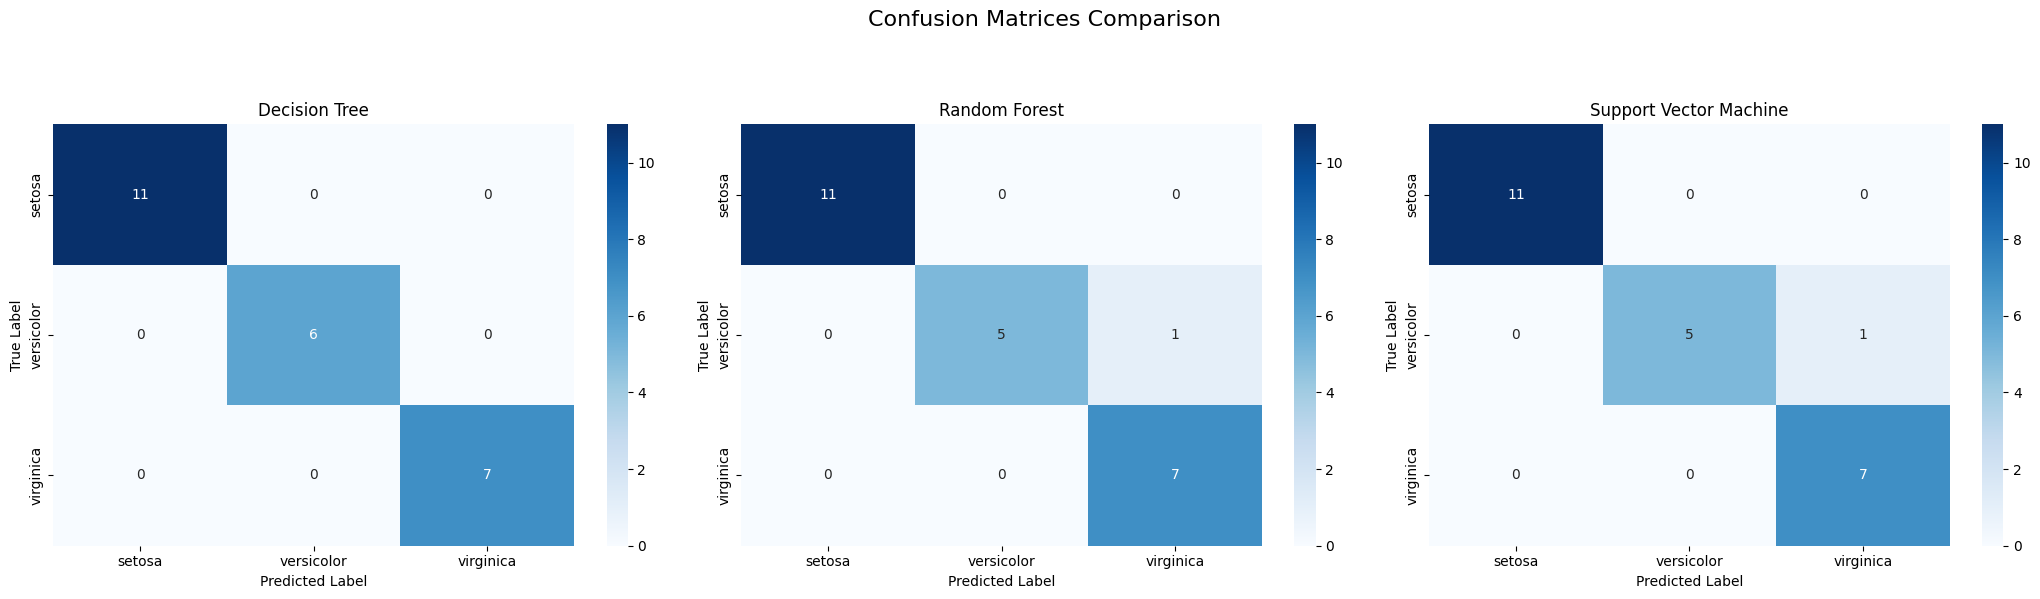

In [ ]:
# Define class_names
class_names = ['setosa', 'versicolor', 'virginica']

# Decision Tree Confusion Matrix
dt_predictions_and_labels = dt_predictions.select("prediction", "label").collect()
y_true_dt = np.array([row.label for row in dt_predictions_and_labels])
y_pred_dt = np.array([row.prediction for row in dt_predictions_and_labels])
cm_dt = confusion_matrix(y_true_dt, y_pred_dt)

# Random Forest Confusion Matrix
rf_predictions_and_labels = rf_predictions.select("prediction", "label").collect()
y_true_rf = np.array([row.label for row in rf_predictions_and_labels])
y_pred_rf = np.array([row.prediction for row in rf_predictions_and_labels])
cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

# SVM Confusion Matrix
svm_predictions_and_labels = svm_predictions.select("prediction", "label").collect()
y_true_svm = np.array([row.label for row in svm_predictions_and_labels])
y_pred_svm = np.array([row.prediction for row in svm_predictions_and_labels])
cm_svm = confusion_matrix(y_true_svm, y_pred_svm)

# Plot all three side-by-side
fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # 1 row, 3 columns

# Plot Decision Tree Confusion Matrix
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# Plot SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title("Support Vector Machine")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

plt.suptitle("Confusion Matrices Comparison", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Interpretation of the Confusion Matrices:

+ **Decision Tree** achieved perfect classification on this test set. There are no misclassifications (off-diagonal are zeros):
    * 'setosa' (class 0), all 11 instances were correctly predicted.
    *  'versicolor' (class 1), all 6 instances were correctly predicted.
    *  'virginica' (class 2), all 7 instances were correctly predicted. .

+ **Random Forest and Support Vector Machine** models achieve similar results. It performed very well, but not perfectly on this specific test set:

    * 'setosa' (class 0): All 11 instances were correctly predicted.
    * 'versicolor' (class 1): 5 instances were correctly predicted, but 1 'versicolor' instance was misclassified as 'virginica' (class 2).
    * 'virginica' (class 2): All 7 instances were correctly predicted

#### **Evaluating the Model**

In [ ]:
# Define the Evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

| Code Snippet                                              | Explanation                                                                                                                                                                                                                                                                                                                                                                                             |
| :-------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **evaluator = MulticlassClassificationEvaluator()** | Initializes an evaluator for multi-class classification tasks.                                                                                                                                                                                                                                                                                             |
| **labelCol="label"**                                  | Specifies that the column named `label` contains the true target values for comparison.                                                                                                                                                                                                                                                                                            |
| **predictionCol="prediction"**                          | Specifies that the column named `prediction` contains the model's predicted class labels. This evaluator will compare the `label` and `prediction` columns to calculate performance metrics.

In [ ]:
# Evaluate the performance of each model
def score_model(predictions, model_name):
    """Calculate and print all 4 metrics for one model."""
    accuracy  = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
    precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
    recall    = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
    f1        = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

    print(f"\n  {model_name}")
    print(f"  {'─'*35}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}% correct)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    return {"model": model_name, "accuracy": accuracy,
            "precision": precision, "recall": recall, "f1": f1}

dt_scores = score_model(dt_predictions, "Decision Tree")
rf_scores = score_model(rf_predictions, "Random Forest")
svm_scores = score_model(svm_predictions, "Support Vector Machine")


  Decision Tree
  ───────────────────────────────────
  Accuracy  : 1.0000  (100.0% correct)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  Random Forest
  ───────────────────────────────────
  Accuracy  : 0.9583  (95.8% correct)
  Precision : 0.9635
  Recall    : 0.9583
  F1-Score  : 0.9578

  Support Vector Machine
  ───────────────────────────────────
  Accuracy  : 0.9583  (95.8% correct)
  Precision : 0.9635
  Recall    : 0.9583
  F1-Score  : 0.9578


In [ ]:
all_scores = [dt_scores, rf_scores, svm_scores]

# Find the maximum Accuracy
max_accuracy = max(s["accuracy"] for s in all_scores)

print("\n\n" + "="*60)
print("  COMPARISON TABLE  ")
print("="*60)
print(f"  {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")

winning_models = []
for s in all_scores:
    marker = " ← BEST" if s["accuracy"] == max_accuracy else ""
    if s["accuracy"] == max_accuracy:
        winning_models.append(s["model"])
    print(f"  {s['model']:<25} {s['accuracy']:>10.4f} {s['precision']:>10.4f} "
          f"{s['recall']:>10.4f} {s['f1']:>10.4f}{marker}")

if len(winning_models) > 1:
    winners_str = ", ".join(winning_models)
    print(f"\n  Winners: {winners_str}  ")
else:
    print(f"\n  Winner: {winning_models[0]} ")



  COMPARISON TABLE  
  Model                       Accuracy  Precision     Recall         F1
  ───────────────────────── ────────── ────────── ────────── ──────────
  Decision Tree                 1.0000     1.0000     1.0000     1.0000 ← BEST
  Random Forest                 0.9583     0.9635     0.9583     0.9578
  Support Vector Machine        0.9583     0.9635     0.9583     0.9578

  Winner: Decision Tree 


## **6.0 Comparative Analysis**

Based on the evaluation results, we can compare the models performance on the Iris dataset.

*   **Performance Comparison**:
    *   **Decision Tree**: 100.00% Accuracy
    *   **Random Forest**: 95.83% Accuracy
    *   **Support Vector Machine**: 95.83% Accuracy

*   **Strengths and Limitations of each model**:
    *   **Decision Tree**:
        * **Strength**: Achieved **perfect accuracy** on this dataset by separating all three classes very well. Its strength lies in interpretability, allowing us to see exactly which features (like petal width/length) lead to a classification.
        * **Limitation**: Highly prone to overfitting and high variance, as it may capture noise in the training data rather than general patterns, which can reduce performance on larger, more complex datasets.
    *   **Random Forest**:
        * **Strength**: An ensemble method that reduces variance and overfitting by combining multiple trees, making it generally more robust for larger datasets.
        * **Limitation**: Had a slight dip in performance (95.83% accuracy) due to one misclassification, incorrectly predicting one 'versicolor' as 'virginica'.  Its slight dip might be due to the small size of the test set.
    *   **Support Vector Machine**:
        * **Strength**: Excellent at finding clear separation boundaries (hyperplanes), which is highly effective for well-defined datasets like Iris.
        * **Limitation**: Achieved 95.83% accuracy, but it can struggle slightly when there is overlap between feature regions, such as between 'versicolor' and 'virginica'.



*   **Justification of the best-performing model**:
The **Decision Tree** is the top performer with 100% accuracy on this specific test set. Its primary advantage, especially for this dataset, is its superior interpretability. Decision Tree allows us to visually trace the exact rules and feature splits that lead to each prediction, offering complete transparency into its decision-making process. This makes it easier to understand why a particular classification was made.

#### **Decision Tree Visualization**


To better understand the Decision Tree's interpretability and how it makes predictions, let's visualize its structure. This will show us the splitting rules at each node and how the model arrives at its classifications.



In [ ]:
# Install graphviz if not already installed
!pip install graphviz

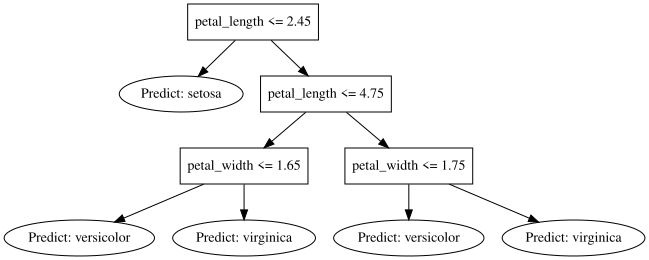

In [ ]:
import graphviz

# This function visualizes a Spark Decision Tree model using Graphviz.
# It converts the model's structure into a DOT string, which Graphviz then renders.

def visualize_dt(model, feature_names, class_names):
    dot_string = 'digraph Tree {\n'

    # Get the tree structure from the model's debug string.
    tree_debug_string = model.toDebugString
    lines = tree_debug_string.split('\n')

    node_count = 0
    # Track parent nodes at each indentation level to connect child nodes correctly.
    parents_at_level = {}

    # Iterate through the tree description, skipping the initial metadata line.
    for line in lines[1:]:
        clean_line = line.strip()
        if not clean_line:
            continue

        # Determine the indentation level to understand the tree hierarchy.
        indent_level = len(line) - len(clean_line)

        current_node_id = f'node{node_count}'
        label = ''
        shape = 'box' # Default shape for decision nodes.

        # Parse decision nodes ('If') and prediction (leaf) nodes ('Predict').
        if clean_line.startswith('If ('):
            label = clean_line.replace('If (', '').replace(')', '')
            # Replace generic 'feature X' with actual feature names for clarity.
            for i, fname in enumerate(feature_names):
                label = label.replace(f'feature {i}', fname)
            shape = 'box'

        elif clean_line.startswith('Predict: '):
            prediction_class_id = int(float(clean_line.replace('Predict: ', '')))
            label = f'Predict: {class_names[prediction_class_id]}'
            shape = 'ellipse' # Shape for leaf nodes (predictions).

        elif clean_line.startswith('Else ('):
            # 'Else' lines are part of decision logic but not separate Graphviz nodes.
            continue

        # If a valid node is parsed, add it to the DOT string.
        if label:
            dot_string += f'    {current_node_id} [label="{label}", shape={shape}];\n'

            # Connect the current node to its parent if it's not the root.
            if indent_level > 0 and (indent_level - 1) in parents_at_level:
                parent_node_id = parents_at_level[indent_level - 1]
                # For simplicity, edge labels (true/false) are omitted in this basic parser.
                dot_string += f'    {parent_node_id} -> {current_node_id};\n'

            # Update the last seen node at this indentation level.
            parents_at_level[indent_level] = current_node_id
            node_count += 1

    dot_string += '}\n'
    return graphviz.Source(dot_string)


# Feature names used in the model (must match the order in VectorAssembler).
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
# Class names corresponding to the numerical labels (0, 1, 2).
class_names = ['setosa', 'versicolor', 'virginica']

# Visualize the best Decision Tree model obtained from cross-validation.
dtg = visualize_dt(dt_best, feature_names, class_names)
dtg

**Interpretation of Decision Tree Diagram**:

*   **Boxes (Internal Nodes)**: Represent decision points. Each box contains a condition, such as `petal_width <= 2.45`. If the condition is true, you follow one path (usually the left branch); if false, you follow another (usually the right branch).
*   **Ellipses (Leaf Nodes)**: These are the final predictions. Once you reach an ellipse, the model has made a classification, such as `Predict: setosa`.
*   **Flow**: The diagram shows a hierarchical flow. Start at the top (the root node) and follow the decisions down until reach a leaf node, which gives the predicted class for a given data.

It starts with a main question, for example: "Is the petal width less than or equal to 2.45 cm?"

*   **If yes (True)**: It goes down one path. For the Iris dataset, flowers with very small petal widths are almost always 'setosa', which are very clearly separated from the other two species. This means a simple question often perfectly identifies 'setosa' flowers.
*   **If no (False)**: It goes down another path, asking another question, perhaps about petal length or petal width.

 The tree keeps splitting the data until it can clearly separate the different Iris species and reach final prediction or until no further informative splits can be made.

+ Misclassifications often occur when different classes in a dataset, such as 'versicolor' and 'virginica', have overlapping feature ranges, making it difficult for models to draw clear separation boundaries.
+ For ensemble methods like Random Forest, a misclassification happens if a majority of its individual trees make the same incorrect decision for a borderline case. Similarly, SVMs might misclassify data points that fall on the 'wrong' side of their separation hyperplane in these overlapping regions.

#### **Support Vector Machine Visualization**

The visualization helps in understanding how the SVM separates the different Iris species.

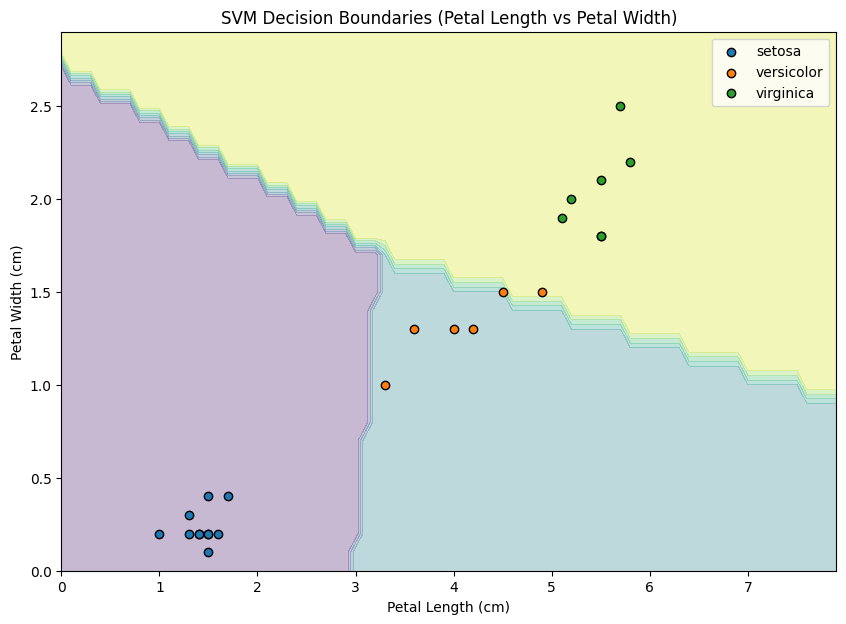

In [ ]:
from pyspark.ml.linalg import Vectors

# 1. Create a mesh grid of points covering the feature range
x_min, x_max = 0.0, 8.0  # Petal Length range
y_min, y_max = 0.0, 3.0  # Petal Width range
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 2. Prepare grid points for prediction
# We use average values for sepal_length and sepal_width to fill the 4D vector
avg_sepal_length = 5.8
avg_sepal_width = 3.0

grid_points = []
for x, y in zip(xx.ravel(), yy.ravel()):
    grid_points.append((Vectors.dense([avg_sepal_length, avg_sepal_width, x, y]),))

grid_df = spark.createDataFrame(grid_points, ["features"])

# 3. Predict using the best SVM model
svm_grid_predictions = svm_best.transform(grid_df)
Z = np.array(svm_grid_predictions.select("prediction").collect()).reshape(xx.shape)

# 4. Plot the results
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Overlay actual test data points
test_pd = test_data.toPandas()
test_features = np.array([f.toArray() for f in test_pd['features']])

for i, class_name in enumerate(class_names):
    idx = test_pd['label'] == i
    plt.scatter(test_features[idx, 2], test_features[idx, 3],
                label=class_name, edgecolors='k')

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('SVM Decision Boundaries (Petal Length vs Petal Width)')
plt.legend()
plt.show()

### **Interpretation**:

This visualization of the SVM decision boundaries shows the regions where the model predicts each class based on petal length and petal width. The shaded areas represent the classification regions, and the scattered points are the actual test data. As shown in the plot, the model successfully separates the setosa class from the others but there is a slight overlap between the versicolor (orange) and virginica (green) regions. Specifically, one 'versicolor' data point falls on the 'wrong side' of the separation boundary, landing in the 'virginica' region. This explains the single misclassification previously observed in the model's confusion matrix.